# XP Gold - Advanced Data Visualization Exercises

In [ ]:
!pip install plotnine plotly seaborn yfinance

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Load local datasets with proper column names
try:
    # Try to load local file with proper headers
    iris = pd.read_csv('Iris_dataset.csv', names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])
except:
    # Fallback to seaborn's iris dataset
    iris = sns.load_dataset('iris')

## Exercise 1: Scatter Plot with Aesthetic Mappings (plotnine)

In [15]:
# Use the iris dataset loaded in imports cell
# (Already loaded: iris = pd.read_csv('Iris_dataset.csv') or sns.load_dataset('iris'))

# Scatter plot with color mapping
plot = (ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
        geom_point(size=3) +
        labs(title='Iris Sepal Dimensions by Species',
             x='Sepal Length (cm)',
             y='Sepal Width (cm)') +
        theme_minimal())

print(plot)

<ggplot: (640 x 480)>


## Exercise 2: Stacked Bar Chart (plotnine)

In [13]:
# Check the structure and column names of the iris dataset
print("Iris dataset info:")
print("Columns:", iris.columns.tolist())
print("\nFirst few rows:")
print(iris.head())
print("\nDataset shape:", iris.shape)

Iris dataset info:
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First few rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset shape: (150, 5)


In [14]:
# Create size categories for stacking
iris['size_category'] = pd.cut(iris['petal_length'], bins=3, labels=['Small', 'Medium', 'Large'])

# Stacked bar chart
plot = (ggplot(iris, aes(x='species', fill='size_category')) +
        geom_bar(position='stack') +
        labs(title='Iris Species Count by Petal Size',
             x='Species',
             y='Count',
             fill='Petal Size') +
        theme_minimal())

print(plot)

<ggplot: (640 x 480)>


## Exercise 3: Facet Wrapping (plotnine)

In [16]:
# Facet wrapped scatter plots by species
plot = (ggplot(iris, aes(x='petal_length', y='petal_width', color='species')) +
        geom_point(size=2) +
        facet_wrap('~species', ncol=2) +
        labs(title='Petal Dimensions by Species (Faceted)',
             x='Petal Length (cm)',
             y='Petal Width (cm)') +
        theme_minimal())

print(plot)

<ggplot: (640 x 480)>


## Exercise 4: Interactive Line Chart - Gapminder (Plotly)

In [17]:
# Load real Gapminder income data
income_data = pd.read_csv('income_per_person_gdppercapita_ppp_inflation_adjusted.csv')

# Reshape data for plotting (wide to long format)
income_melted = income_data.melt(id_vars=['country'], 
                                var_name='year', 
                                value_name='gdp_per_capita')
income_melted['year'] = income_melted['year'].astype(int)

# Filter for recent years and specific countries
recent_data = income_melted[income_melted['year'] >= 2000]
countries_of_interest = ['United States', 'China', 'Germany', 'Japan', 'India']
filtered_data = recent_data[recent_data['country'].isin(countries_of_interest)]

# Interactive line chart
fig = px.line(filtered_data, 
              x='year', 
              y='gdp_per_capita',
              color='country',
              title='GDP per Capita Over Time (2000-2023)',
              labels={'gdp_per_capita': 'GDP per Capita (PPP)', 'year': 'Year'})

fig.show()

## Exercise 5: 3D Scatter Plot - Iris (Plotly)

In [18]:
# 3D scatter plot with Iris data
fig = px.scatter_3d(iris,
                    x='sepal_length',
                    y='sepal_width', 
                    z='petal_length',
                    color='species',
                    title='3D Iris Species Visualization',
                    labels={'sepal_length': 'Sepal Length',
                           'sepal_width': 'Sepal Width',
                           'petal_length': 'Petal Length'},
                    hover_name='species')

fig.show()

## Exercise 6: Interactive Heatmap - Flight Data (Plotly)

In [19]:
# Load real airline delay data
delay_data = pd.read_csv('Airline_Delay_Cause.csv')

# Create heatmap of average delays by carrier and month
heatmap_data = delay_data.groupby(['carrier_name', 'month'])['arr_delay'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='carrier_name', columns='month', values='arr_delay')

# Interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=heatmap_pivot.values,
    x=heatmap_pivot.columns,
    y=heatmap_pivot.index,
    colorscale='RdYlBu_r',
    hovertemplate='Carrier: %{y}<br>Month: %{x}<br>Avg Delay: %{z:.1f} min<extra></extra>'))

fig.update_layout(title='Average Flight Delays by Airline and Month',
                  xaxis_title='Month',
                  yaxis_title='Airline Carrier',
                  height=600)

fig.show()

## Exercise 7: Large Dataset Time-Series (Matplotlib) - Stock Data

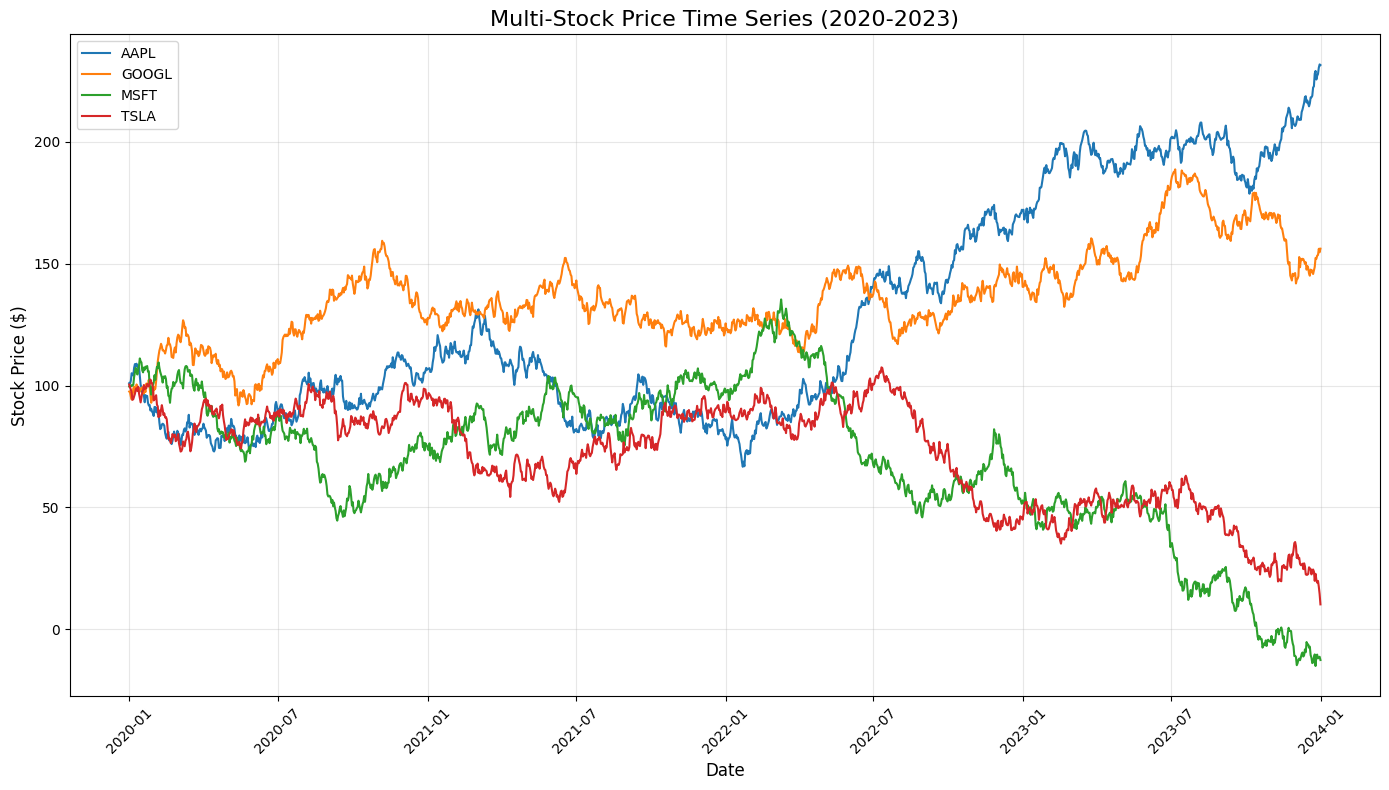

In [20]:
#  synthetic stock price data
dates = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
np.random.seed(42)

# Creating multiple stock series
stocks = ['AAPL', 'GOOGL', 'MSFT', 'TSLA']
stock_data = {}

for stock in stocks:
    
    price = 100 + np.cumsum(np.random.randn(len(dates)) * 2)
    stock_data[stock] = price

df_stocks = pd.DataFrame(stock_data, index=dates)

# Large time-series visualization with interactivity
fig, ax = plt.subplots(figsize=(14, 8))

for stock in stocks:
    ax.plot(df_stocks.index, df_stocks[stock], label=stock, linewidth=1.5)

ax.set_title('Multi-Stock Price Time Series (2020-2023)', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Stock Price ($)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Exercise 8: Interactive Data Exploration - Flight Delays Analysis

In [21]:
# Load real Airlines dataset
airlines_data = pd.read_csv('Airlines.csv')

# Sample data for better visualization (dataset is large)
sample_data = airlines_data.sample(n=5000, random_state=42)

# Create derived features
sample_data['delay_minutes'] = sample_data['Delay'] * 30  # Convert binary to approximate minutes
sample_data['flight_distance'] = sample_data['Length']  # Use flight length as distance

# Interactive scatter plot with real data
fig = px.scatter(sample_data, 
                 x='Time', 
                 y='delay_minutes',
                 color='Airline',
                 size='flight_distance',
                 hover_data=['Flight', 'AirportFrom', 'AirportTo'],
                 title='Flight Analysis: Departure Time vs Delay Status',
                 labels={'Time': 'Departure Time (24h format)',
                         'delay_minutes': 'Delay Status (0=On Time, 30=Delayed)',
                         'flight_distance': 'Flight Length (minutes)'})

fig.update_layout(height=600)
fig.show()

# Summary statistics by airline
print("\\nDelay Statistics by Airline:")
delay_stats = sample_data.groupby('Airline').agg({
    'Delay': ['count', 'sum', 'mean'],
    'Length': 'mean'
}).round(3)
delay_stats.columns = ['Total_Flights', 'Delayed_Flights', 'Delay_Rate', 'Avg_Flight_Length']
print(delay_stats)

\nDelay Statistics by Airline:
         Total_Flights  Delayed_Flights  Delay_Rate  Avg_Flight_Length
Airline                                                               
9E                 197               81       0.411             95.888
AA                 459              183       0.399            173.464
AS                 107               37       0.346            169.449
B6                 169               89       0.527            174.917
CO                 213              108       0.507            195.188
DL                 537              231       0.430            152.352
EV                 234              104       0.444             94.641
F9                  50               23       0.460            161.940
FL                 189               51       0.270            131.005
HA                  56               12       0.214             82.732
MQ                 341              119       0.349            105.088
OH                 121               33       